In [1]:
import os
import sys
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cau_package_path = "../"
_normpath = os.path.normpath(cau_package_path)
if not os.path.normpath(_normpath) in sys.path:
    sys.path.append(_normpath)

import cmb_anomaly_utils as cau

In [2]:
from matplotlib.lines import Line2D

plt.rcParams['text.usetex'] = True
plt.rc('font', family='serif')
plt.rc('legend', facecolor='white', edgecolor='k', framealpha=1)
plt.rcParams['xtick.major.size'] = 3.5
plt.rcParams['ytick.major.size'] = 3.5
plt.rcParams['xtick.labelsize']  = 12
plt.rcParams['ytick.labelsize']  = 12

def custom_save_fig(fig, fdir, fname, do_plt_save = False):
    cau.output.ensure_dir(fdir)
    for ftype in ['.png', '.pdf']:
        fpath    = fdir + fname + ftype
        if not do_plt_save:
            fig.savefig(fpath, facecolor=(1,1,1,0), dpi=300, transparent=True)
        else:
            plt.savefig(fpath, dpi = 300, transparent = True)

In [11]:
cleaning_pipeline               = "commander"
run_inputs  = cau.run_utils.RunInputs()
run_inputs.max_sim_num          = 1000
common_cmb_data_path            = "../"
run_inputs.mask_fpath           = "{}/input/cmb_fits_files/COM_Mask_CMB-common-Mask-Int_2048_R3.00.fits".format(common_cmb_data_path)
run_inputs.cmb_fpath            = "{}/input/cmb_fits_files/COM_CMB_IQU-{}_2048_R3.00_full.fits".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.sims_path            = "{}/input/{}_sims/".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.noise_path           = "{}/input/{}_noise/".format(common_cmb_data_path, cleaning_pipeline)
run_inputs.geom_flag            = cau.const.CAP_FLAG
run_inputs.measure_flag         = cau.const.VAR_FLAG
run_inputs.is_masked            = True
run_inputs.min_pix_ratio        = 0.1
run_inputs.nside                = 64
run_inputs.dir_nside            = 16
run_inputs.geom_start           = 0
run_inputs.geom_stop            = 180
run_inputs.delta_geom_samples   = 1
run_inputs.stripe_thickness     = 10
run_inputs.lmax                 = 30

base_path                       = "./output/{}_{}_min_pix_ratio_{:.1f}/".format(cleaning_pipeline, run_inputs.nside, run_inputs.min_pix_ratio)
plot_path                       = base_path.replace("output/", "plot/")
for _path in [base_path, plot_path]: cau.output.ensure_dir(_path)

map_disc_sizes = cau.stat_utils.get_range(10, 90, 5)
# map_disc_sizes = np.concatenate((cau.stat_utils.get_range(4, 9, 1), cau.stat_utils.get_range(10, 90, 5)))
max_sim_num = run_inputs.max_sim_num

### Reading foreground Map

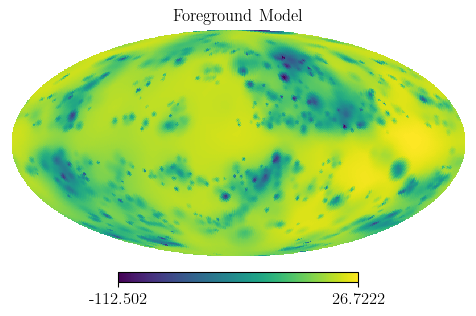

In [12]:
foreground_map = hp.read_map("./input/map_foreground_model_hansen2023_muK_ringordering_nside128.fits")
foreground_map = hp.ud_grade(foreground_map, 64)

fig = plt.figure(1, figsize=(5,3))
hp.mollview(foreground_map, fig, title = r"Foreground Model")

### Computing local variance maps

In [21]:
map_gen = cau.run_utils.MapGenerator(**run_inputs.to_kwargs())


print("Reading CMB Data:")
cmb_map = map_gen.create_cmb_map()
cau.map_utils.remove_monopole_dipole(cmb_map)
print("\t-Done-")

dir_lat, dir_lon = cau.coords.get_healpix_latlon(run_inputs.dir_nside)
ndir = cau.coords.get_npix(run_inputs.dir_nside)
measure_dir_indices = np.arange(ndir, dtype=int)

foreground_pix_map = map_gen.create_dummy_map()
foreground_pix_map.raw_data = foreground_map
foreground_pix_map.mask     = cmb_map.mask

cmb_measure = np.zeros(ndir)
foreground_measure = np.zeros(ndir)

for disc_size in map_disc_sizes:
    print("Disc Size(deg): {:2}".format(disc_size))
    print("Calculating Cap Measures:")
    for dir_i in measure_dir_indices:
        print(f"\t{dir_i}/{ndir - 1}\r", end="")
        # Separating Common Geometry -> Top cap & Bottom cap
        plat, plon = dir_lat[dir_i], dir_lon[dir_i]
        foreground_pix_map.change_pole(plat, plon)
        top_filter, bottom_filter = cau.geometry.get_top_bottom_caps_selection_filters( pix_map = foreground_pix_map,
                                                                                        cap_angle = disc_size)
        visible_ratio = top_cap.get_visible_pixels_ratio()
        # CMB measure
        top_cap, bottom_cap = cau.geometry.get_top_bottom_caps_by_filters( pix_map = cmb_map,
                                                                           top_sel = top_filter,
                                                                           bottom_sel = bottom_filter)
        cmb_measure[dir_i] = \
            np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                cau.measure.func_dict[run_inputs.measure_flag](top_cap, bottom_cap, **run_inputs.to_kwargs())
        # Foreground model measure]
        top_cap, bottom_cap = cau.geometry.get_top_bottom_caps_by_filters( pix_map = foreground_pix_map,
                                                                           top_sel = top_filter,
                                                                           bottom_sel = bottom_filter)
        foreground_measure[dir_i] = \
            np.nan if visible_ratio < run_inputs.min_pix_ratio else \
                cau.measure.func_dict[run_inputs.measure_flag](top_cap, bottom_cap, **run_inputs.to_kwargs())
    print("")
    
    _mflag = run_inputs.measure_flag.lower()
    _series = cleaning_pipeline
    np.savetxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt", cmb_measure)
    np.savetxt(base_path + f"{_series}_foreground_{_mflag}_{disc_size:02}cap.txt", foreground_measure)

Reading CMB Data:
	-Done-
Disc Size(deg): 10.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 15.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 20.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 25.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 30.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 35.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 40.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 45.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 50.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 55.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 60.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 65.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 70.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 75.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 80.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 85.0
Calculating Cap Measures:
	3071/3071
Disc Size(deg): 90.0
Calculating Cap Measures:

### Plot raw local variances

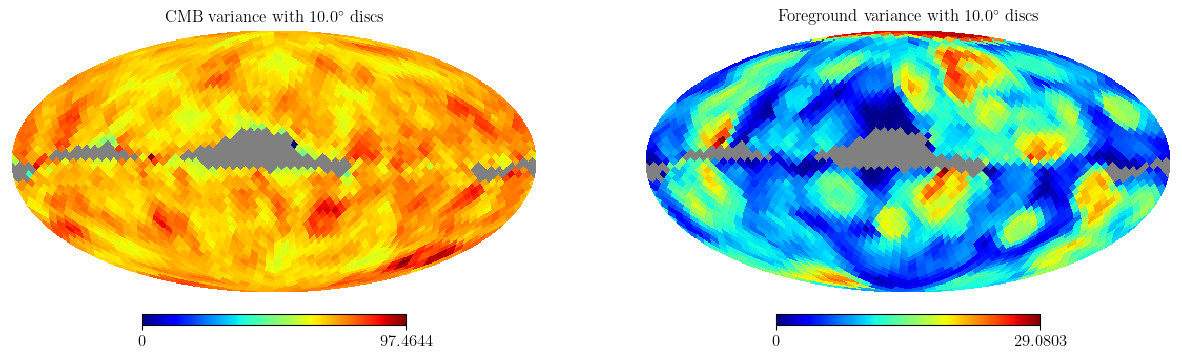

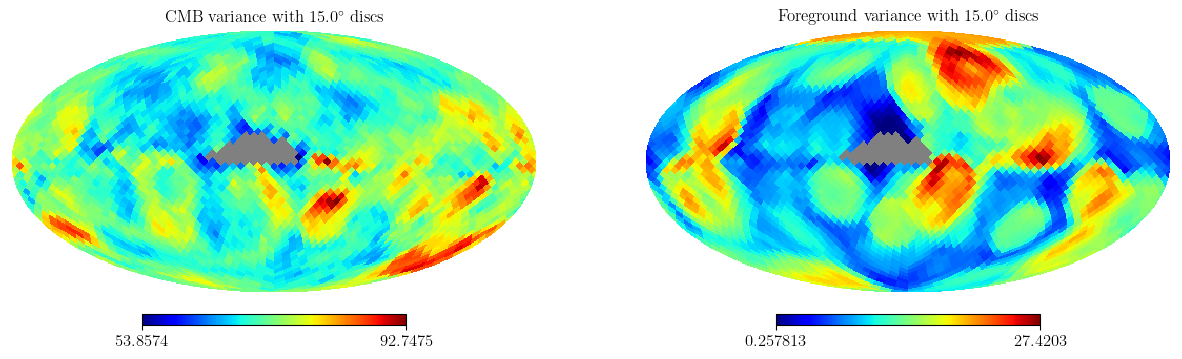

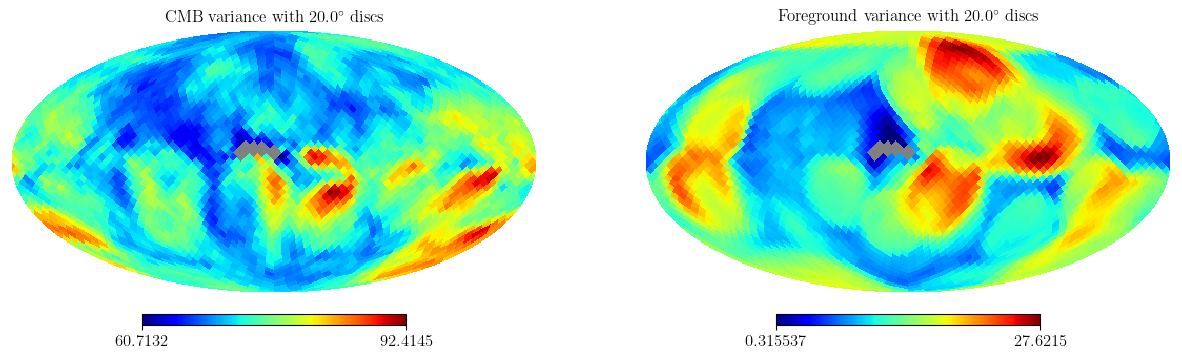

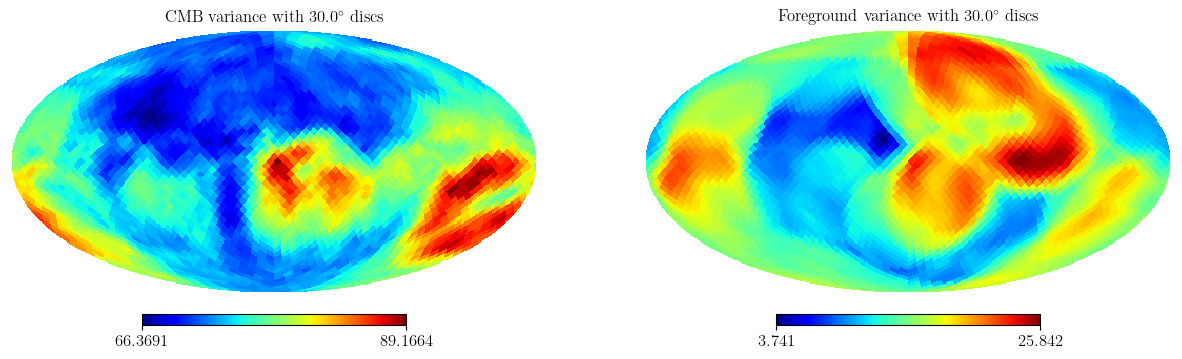

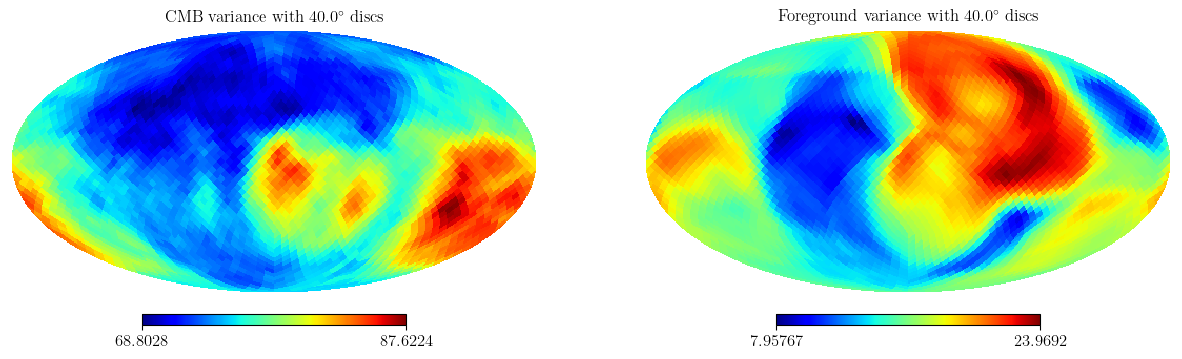

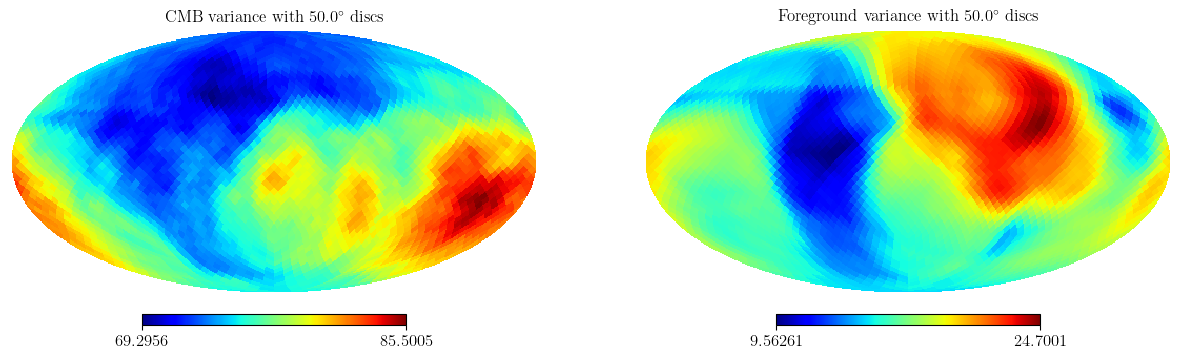

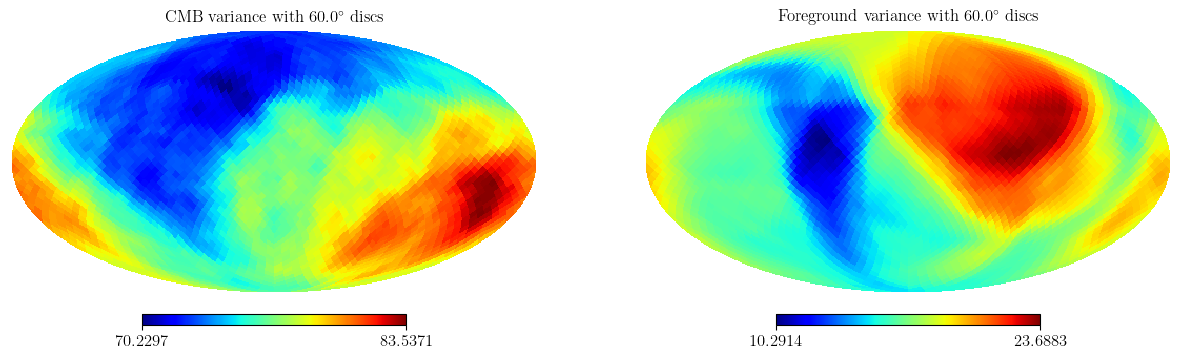

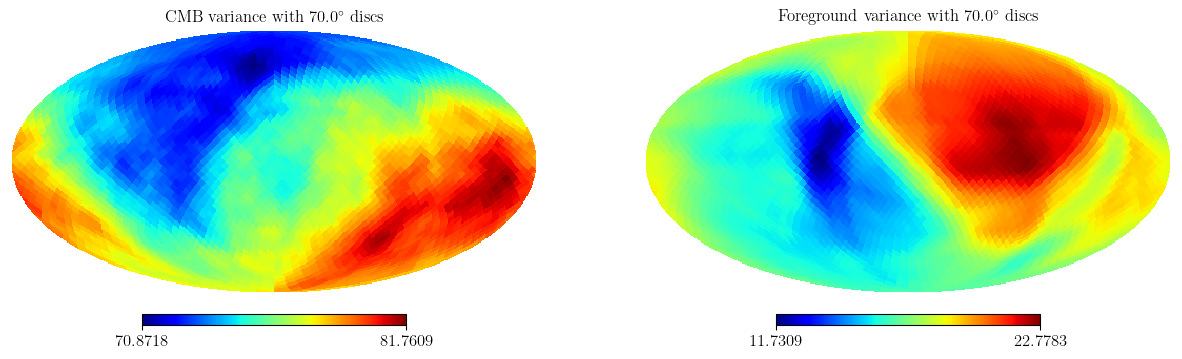

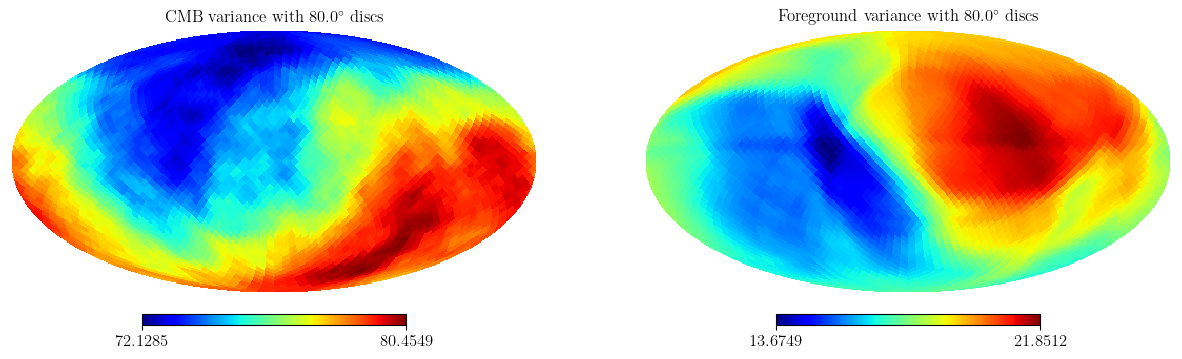

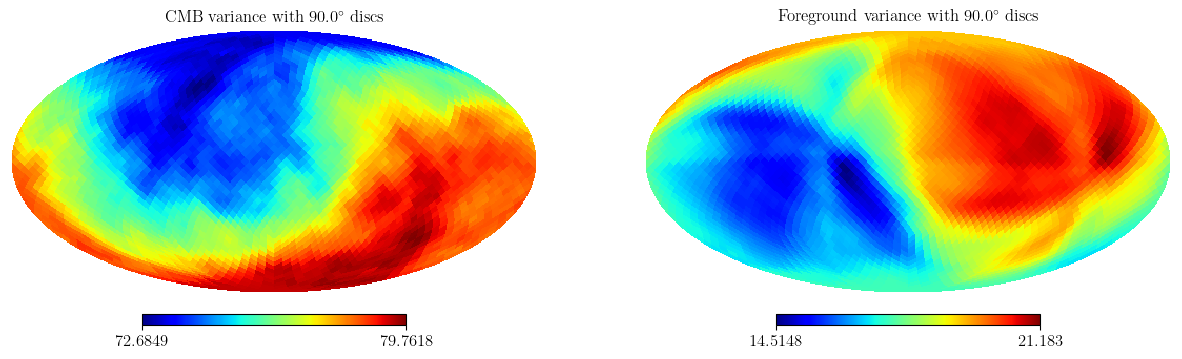

In [43]:
_mflag = run_inputs.measure_flag.lower()
_series = cleaning_pipeline

for disc_size in [10., 15., 20., 30., 40., 50., 60., 70., 80., 90.]:
    #CMB measure
    '''cmb_msr'''
    cmb_msr_map             = np.loadtxt(base_path + f"{_series}_cmb_{_mflag}_{disc_size:02}cap.txt")
    foreground_msr_map      = np.loadtxt(base_path + f"{_series}_foreground_{_mflag}_{disc_size:02}cap.txt")

    # mean_field = np.mean(sims_msr, axis = 0)
    # var_msr = np.var(sims_msr, axis = 0)
    # local_msr_map = (sims_local_msr_map[700] - mean_field) / var_msr
    
    _fig, (ax1, ax2) = plt.subplots(ncols=2)

    _fig.set_size_inches(15,5)

    plt.axes(ax1)
    hp.mollview(cmb_msr_map,
                title = r"CMB variance with ${}^\circ$ discs".format(disc_size),
                cmap = "jet",
                xsize = 500,
                # fontsize = dict(title = 20,
                #                 cbar_tick_label = 15,),
                hold=True
                )
    
    plt.axes(ax2)
    hp.mollview(foreground_msr_map,
                title = r"Foreground variance with ${}^\circ$ discs".format(disc_size),
                cmap = "jet",
                xsize = 500,
    #             fontsize = dict(title = 20,
    #                             cbar_tick_label = 15),
                hold=True
                )
    plt.show()